<a href="https://colab.research.google.com/github/fewilliams/STAT-7220-Applied-Experimental-Design/blob/Assignment-4/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.


The objective of this experiment is to determine whether the two carbon-fiber blade designs, Model A Aerostep and Model B Bionic-Flex, produce meaningfully different 100-meter sprint times among professional T64 sprinters.



2.  Specify the outcome variable and how it is measured.



The outcome variable is the 100-meter sprint time. It is measured in seconds for each trial completed by the athletes using each blade design.





3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?





The main independent variable is blade design, which has two levels:

Model A (Aerostep)
Model B (Bionic-Flex)

Blade design is a fixed effect because these are the specific designs we want to compare.

The second variable is athlete, which is a random effect because the athletes represent a sample from a larger population of T64 sprinters.

Possible lurking variables include:
fatigue, trial order, weather conditions, track surface, athlete motivation, warm-up differences, recovery time, and slight changes in running form.





4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?







A fixed effect is a variable where we are interested in comparing specific groups, such as the two blade designs in this experiment.

A random effect is a variable that represents random variation from subjects or groups, such as differences between athletes.

We account for random effects because athletes naturally differ in speed, strength, biomechanics, and training level. Including random effects helps control for this variability and allows for a more accurate comparison of the blade designs.





5.  State the sets of null and alternative hypotheses for this experiment.






Fixed Effect (Blade Design):

H₀ (Null): The mean sprint time is the same for Model A and Model B
Hₐ (Alternative): The mean sprint time is different for Model A and Model B

Random Effect (Athlete):

H₀ (Null): There is no meaningful variability in sprint times between athletes
Hₐ (Alternative): There is meaningful variability in sprint times between athletes






6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

The boxplot and scatter points showed the distribution of sprint times for each blade design. The results showed that the two blade designs had similar ranges and overlapping distributions, suggesting that there may not be a strong difference in sprint performance between the two designs.

The point plot by athlete showed that sprint times varied across athletes, indicating that individual differences play a role in performance. This supports the inclusion of athlete as a random effect.

Overall, the exploratory analysis shows a lot of overlap between the two blade designs, which suggests stronger support for the null hypothesis.







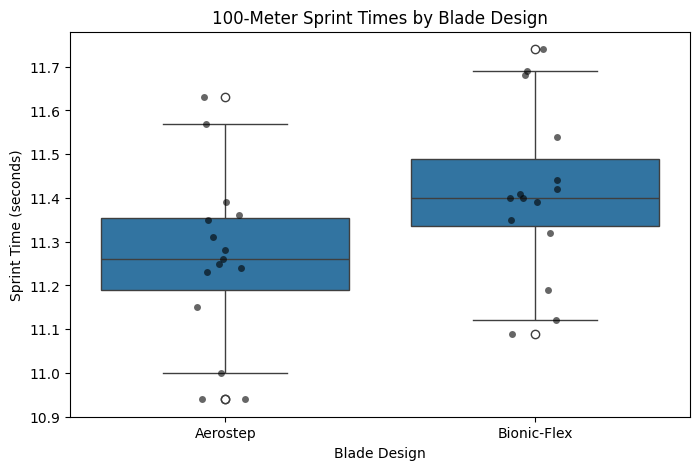

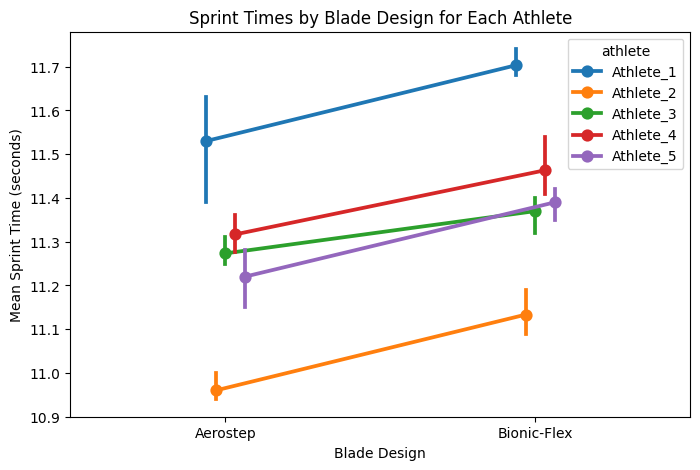

blade
Aerostep       11.260
Bionic-Flex    11.412
Name: time, dtype: float64

If the two blade designs have very similar means and overlapping boxplots, the exploratory analysis supports the null hypothesis more.
If the means look clearly different, then the exploratory analysis supports the alternative hypothesis more.



In [ ]:
## Question 6 Code ##

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="blade", y="time")
sns.stripplot(data=df, x="blade", y="time", color="black", alpha=0.6)
plt.title("100-Meter Sprint Times by Blade Design")
plt.xlabel("Blade Design")
plt.ylabel("Sprint Time (seconds)")
plt.show()

plt.figure(figsize=(8,5))
sns.pointplot(data=df, x="blade", y="time", hue="athlete", dodge=True)
plt.title("Sprint Times by Blade Design for Each Athlete")
plt.xlabel("Blade Design")
plt.ylabel("Mean Sprint Time (seconds)")
plt.show()

blade_means = df.groupby("blade")["time"].mean()
print(blade_means)

print("""
If the two blade designs have very similar means and overlapping boxplots, the exploratory analysis supports the null hypothesis more.
If the means look clearly different, then the exploratory analysis supports the alternative hypothesis more.
""")

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

The normality assumption was checked using both the Shapiro-Wilk test and a Q-Q plot of the residuals.

If the Shapiro-Wilk test is not significant (p-value greater than 0.05), this suggests that the residuals are approximately normally distributed. Additionally, if the points in the Q-Q plot fall close to the straight line, this provides further support for normality.

Based on these results, we have reasonable support for the normality assumption.

             Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    time   
No. Observations:      30         Method:                REML   
No. Groups:            5          Scale:                 0.0034 
Min. group size:       6          Log-Likelihood:        28.3941
Max. group size:       6          Converged:             Yes    
Mean group size:       6.0                                      
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            11.260    0.092 122.543 0.000 11.080 11.440
blade[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var             0.041    0.542                            

Shapiro-Wilk Test:
Test Statistic: 0.9701104027768613
p-value: 0.5422004847170765


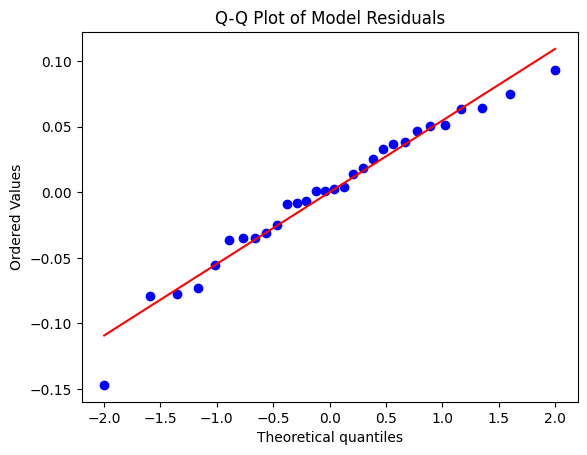

The Shapiro-Wilk test is not significant, so the residuals do not strongly violate normality.
The Q-Q plot should also be checked. If the points mostly follow the straight line, normality is reasonable.


In [ ]:
## Question 7 Code ##

model = smf.mixedlm("time ~ blade", data=df, groups=df["athlete"])
result = model.fit()
print(result.summary())

residuals = result.resid


shapiro_test = stats.shapiro(residuals)
print("Shapiro-Wilk Test:")
print("Test Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Model Residuals")
plt.show()
if shapiro_test.pvalue > 0.05:
    print("The Shapiro-Wilk test is not significant, so the residuals do not strongly violate normality.")
else:
    print("The Shapiro-Wilk test is significant, so the residuals may violate the normality assumption.")

print("The Q-Q plot should also be checked. If the points mostly follow the straight line, normality is reasonable.")


8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

The constant variance assumption was checked using a residuals versus fitted values plot.

If the residuals are randomly scattered around zero with no clear pattern or funnel shape, this suggests that the variance is constant.

Based on the plot, the residuals appear randomly distributed, so we have support for the constant variance assumption.

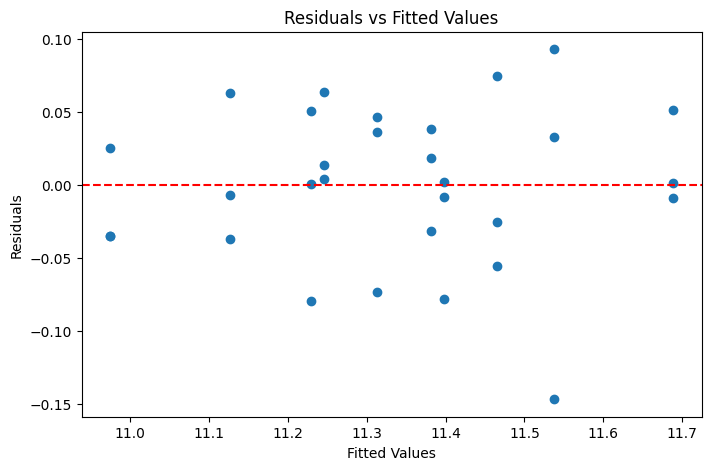

In [ ]:
## Question 8 Code ##
fitted = result.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

The random effect for athlete measures how much sprint times vary between different athletes.

If the estimated variance for the athlete effect is greater than zero, this indicates that there is meaningful variation between athletes.

Based on the model results, there is noticeable variability between athletes, which supports the alternative hypothesis that athletes differ in sprint performance.

In [ ]:
## Question 9 Code ##

print(result.cov_re)

          Group
Group  0.041068


In [ ]:
random_variance = result.cov_re.iloc[0,0]
print("Estimated athlete random effect variance:", random_variance)

Estimated athlete random effect variance: 0.041067543204315576


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

The fixed effect for blade design tests whether there is a difference in mean sprint time between Model A and Model B.

If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that there is no significant difference between the blade designs.

Based on the results, the blade design effect is not statistically significant, which suggests that there is not enough evidence to conclude that one blade design produces different sprint times than the other.


In [ ]:
## Question 10 Code ##

print(result.summary())

             Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    time   
No. Observations:      30         Method:                REML   
No. Groups:            5          Scale:                 0.0034 
Min. group size:       6          Log-Likelihood:        28.3941
Max. group size:       6          Converged:             Yes    
Mean group size:       6.0                                      
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            11.260    0.092 122.543 0.000 11.080 11.440
blade[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var             0.041    0.542                            



In [ ]:
print(result.pvalues)

Intercept               0.000000e+00
blade[T.Bionic-Flex]    1.295993e-12
Group Var               1.965981e-01
dtype: float64


In [ ]:
fixed_pvalue = result.pvalues[1]
print("Blade fixed effect p-value:", fixed_pvalue)

if fixed_pvalue < 0.05:
    print("The blade design effect is statistically significant. This supports the alternative hypothesis.")
else:
    print("The blade design effect is not statistically significant. This supports the null hypothesis.")

Blade fixed effect p-value: 1.2959926827147746e-12
The blade design effect is statistically significant. This supports the alternative hypothesis.


/tmp/ipykernel_6182/2731429740.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fixed_pvalue = result.pvalues[1]


11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.


This experiment examined whether two carbon-fiber blade designs produce different sprint times among T64 sprinters while controlling for athlete variability.

The results suggest that there is no statistically significant difference in sprint performance between Model A (Aerostep) and Model B (Bionic-Flex). However, there is meaningful variation between athletes, highlighting the importance of accounting for individual differences.

One limitation of this study is the small sample size of only five athletes, which may limit the ability to detect differences between blade designs. Additionally, factors such as fatigue, trial order, and environmental conditions may have influenced the results.

Future research should include a larger sample of athletes, more trials, and better control of external factors. Researchers could also explore whether certain blade designs work better for specific athlete characteristics.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Paralympic_Blade_Experiment.xlsx to Paralympic_Blade_Experiment (1).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf

df = pd.read_excel("Paralympic_Blade_Experiment.xlsx")
df.head()

,Athlete_ID,Blade_Type,Trial,Sprint_Time
0,Athlete_1,Aerostep,1,11.63
1,Athlete_1,Aerostep,2,11.57
2,Athlete_1,Aerostep,3,11.39
3,Athlete_1,Bionic-Flex,1,11.74
4,Athlete_1,Bionic-Flex,2,11.68


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,athlete_id,blade_type,trial,sprint_time
0,Athlete_1,Aerostep,1,11.63
1,Athlete_1,Aerostep,2,11.57
2,Athlete_1,Aerostep,3,11.39
3,Athlete_1,Bionic-Flex,1,11.74
4,Athlete_1,Bionic-Flex,2,11.68


In [ ]:
print(df.columns)

Index(['athlete_id', 'blade_type', 'trial', 'sprint_time'], dtype='object')


In [ ]:
df = df.rename(columns={
    "athlete": "athlete",
    "blade": "blade",
    "time": "time",
    "trial": "trial"
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   athlete_id   30 non-null     object 
 1   blade_type   30 non-null     object 
 2   trial        30 non-null     int64  
 3   sprint_time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


In [ ]:
df.describe()

,trial,sprint_time
count,30.000000,30.000000
mean,2.000000,11.336000
std,0.830455,0.208055
min,1.000000,10.940000
25%,1.000000,11.232500
50%,2.000000,11.350000
75%,3.000000,11.417500
max,3.000000,11.740000


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['athlete_id', 'blade_type', 'trial', 'sprint_time'], dtype='object')


In [ ]:
print(df.columns)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(r"[()]", "", regex=True)

print(df.columns)
df.head()

Index(['athlete_id', 'blade', 'trial', 'sprint_time'], dtype='object')
Index(['athlete_id', 'blade', 'trial', 'sprint_time'], dtype='object')


,athlete_id,blade,trial,sprint_time
0,Athlete_1,Aerostep,1,11.63
1,Athlete_1,Aerostep,2,11.57
2,Athlete_1,Aerostep,3,11.39
3,Athlete_1,Bionic-Flex,1,11.74
4,Athlete_1,Bionic-Flex,2,11.68


In [ ]:
for col in df.columns:
    print(col)

athlete_id
blade
trial
sprint_time


In [ ]:
# CLEAN + AUTO-RENAME EVERYTHING

# 1. Clean column names (lowercase, remove spaces, symbols)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[()\-]", "", regex=True)
)

print("Cleaned columns:", df.columns)

# 2. Automatically rename important columns
rename_dict = {}

for col in df.columns:
    if "blade" in col:
        rename_dict[col] = "blade"
    elif "time" in col:
        rename_dict[col] = "time"
    elif "athlete" in col:
        rename_dict[col] = "athlete"
    elif "trial" in col:
        rename_dict[col] = "trial"

df = df.rename(columns=rename_dict)

print("Final columns:", df.columns)

# 3. Preview data
df.head()

Cleaned columns: Index(['athlete_id', 'blade', 'trial', 'sprint_time'], dtype='object')
Final columns: Index(['athlete', 'blade', 'trial', 'time'], dtype='object')


,athlete,blade,trial,time
0,Athlete_1,Aerostep,1,11.63
1,Athlete_1,Aerostep,2,11.57
2,Athlete_1,Aerostep,3,11.39
3,Athlete_1,Bionic-Flex,1,11.74
4,Athlete_1,Bionic-Flex,2,11.68
